In [4]:
# CONTOUR DETECTION AND ANALYSIS
# TR : Görüntü İşleme ve Kontur Analizi

In [5]:

# Bu konu, gri tonlamalı veya renkli görüntüler üzerinde eşikleme (thresholding), 
# morfolojik işlemler ve kontur tespiti (contour detection) tekniklerini kapsar.
# Amaç, nesnelerin sınırlarını belirlemek, konturları tespit etmek, 
# ve bu konturları görselleştirerek görüntüdeki yapısal özellikleri analiz etmektir.

# Bu tür işlemler, nesne tanıma, sayma, bölütleme (segmentation) ve 
# görsel analiz uygulamalarında sıklıkla kullanılır.

# Bu konu altında yapılan işlemler:

    # 1. Görüntü Okuma
        # Renkli (BGR) ve gri tonlamalı olarak aynı görüntü okunur.
        # Renkli görüntü görselleştirme için, gri görüntü ise analiz için kullanılır.

    # 2. Eşikleme (Thresholding)
        # Görüntüdeki pikseller belirli bir değerin üzerinde veya altında olacak şekilde
        # siyah-beyaz (binary) hâle getirilir.
        # Bu, nesne sınırlarını belirginleştirmek için yapılır.

    # 3. Kontur Bulma (Contour Detection)
        # Binary görüntü üzerindeki nesnelerin dış hatları (konturları) bulunur.
        # cv2.findContours() fonksiyonu ile elde edilen konturlar,
        # nesnelerin çevresini belirlemek için kullanılır.

    # 4. Kontur Çizimi (Contour Drawing)
        # Bulunan konturlar orijinal (renkli) görüntü üzerinde çizilerek görselleştirilir.
        # Renk ve kalınlık belirlenerek, nesne sınırları açıkça vurgulanır.

    # 5. Morfolojik İşlemler (Morphological Operations)
        # Kontur tespitini iyileştirmek için görüntüdeki küçük boşluklar kapatılır.
        # "Closing" işlemi ile daha düzgün ve bütünsel konturlar elde edilir.

    # 6. Görselleştirme
        # Elde edilen threshold (binary) ve kontur çizilmiş görüntüler ayrı pencerelerde gösterilir.
        # Kullanıcı bir tuşa basana kadar pencereler açık kalır.

# Bu konu, özellikle:
# - Nesne tespiti
# - Şekil tanıma
# - Görüntü segmentasyonu
# - Eğitim ve analiz amaçlı kontur görselleştirme uygulamaları için kullanılır.

# Kod Uygulaması:

In [6]:
import cv2  # OpenCV kütüphanesini içe aktarır. 
#Görüntü okuma, yazma, filtreleme, yüz tanıma gibi işlemler için kullanılır.

import matplotlib.pyplot as plt  # Matplotlib kütüphanesinden pyplot modülünü içe aktarır. 
# Görüntüleri, grafik ve histogramları görselleştirmek için kullanılır.

import numpy as np  # NumPy kütüphanesini "np" kısaltmasıyla içe aktarır. 
# Diziler (array) oluşturmak ve matematiksel işlemler yapmak için kullanılır.


In [7]:
my_bgr_img = cv2.imread("./Hafta_7/bonus.jpg")  
# "./Hafta_7/bonus.jpg" yolundaki resmi BGR renk formatında okur
# ve my_bgr_img değişkenine atar. (BGR = Blue, Green, Red)

my_gray_img = cv2.imread("./Hafta_7/bonus.jpg", 0)  
# Aynı resmi gri (grayscale) formatında okur ve my_gray_img değişkenine atar.
# 0 parametresi gri modda okumayı belirtir.


In [8]:
ret, thresh = cv2.threshold(my_gray_img, 127, 255, cv2.THRESH_BINARY)
# my_gray_img üzerinde eşikleme uygular.
# 127 değerinden büyük pikselleri 255 yapar, küçük pikselleri 0 yapar.
# ret değişkeni eşik değeri (burada 127), thresh değişkeni ise eşiklenmiş görüntüdür.

contours, hierarchy = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
# thresh görüntüsündeki dış konturları bulur.
# contours = bulunan konturların listesi
# hierarchy = konturların hiyerarşik ilişkilerini tutar
# cv2.RETR_EXTERNAL = sadece dış konturları al
# cv2.CHAIN_APPROX_SIMPLE = gereksiz noktaları sıkıştırarak kaydet

cv2.drawContours(my_bgr_img, contours, -1, (0,255,0), 2)
# my_bgr_img üzerinde bulunan tüm konturları çizer
# -1 = tüm konturları çiz
# (0,255,0) = yeşil renk
# 2 = çizgi kalınlığı

cv2.imshow("COUNTURED IMAGE", my_bgr_img)
# Konturları çizdiğimiz BGR görüntüyü ekranda göster

cv2.imshow("THRESH IMAGE", thresh)
# Eşiklenmiş (binary) görüntüyü ekranda göster

cv2.waitKey(0)
# Kullanıcı herhangi bir tuşa basana kadar pencereleri açık tut

cv2.destroyAllWindows()
# Açık olan tüm OpenCV pencerelerini kapat


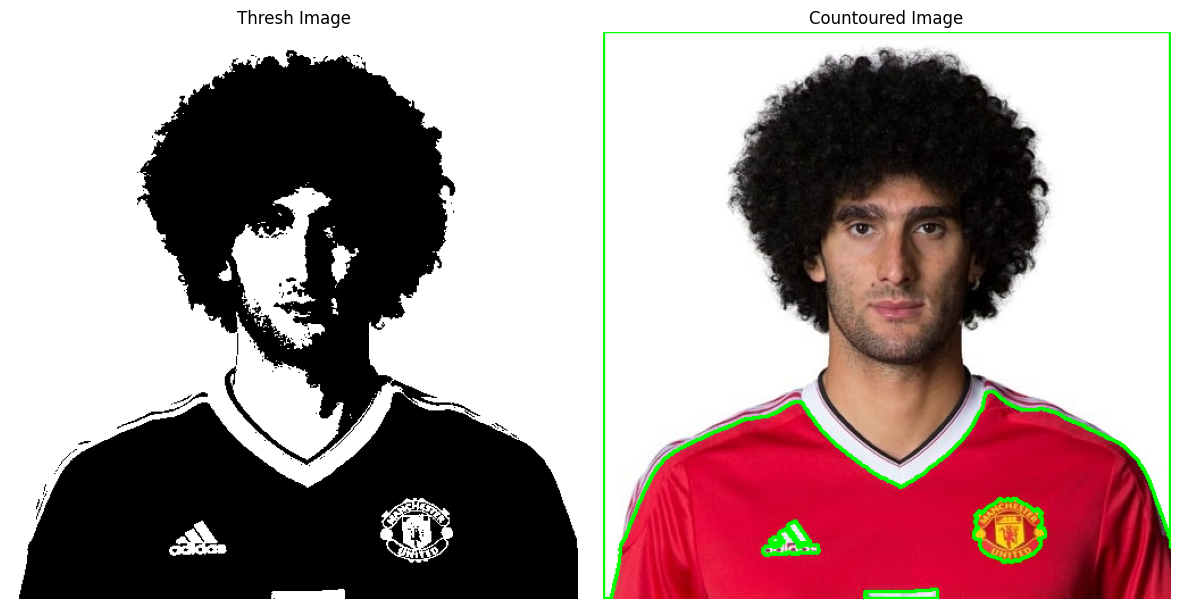

In [12]:
import cv2
from matplotlib import pyplot as plt

# Görüntüyü BGR ve gri olarak oku
my_bgr_img = cv2.imread("./Hafta_7/bonus.jpg")
my_gray_img = cv2.imread("./Hafta_7/bonus.jpg", 0)

# Eşikleme uygula
ret, thresh = cv2.threshold(my_gray_img, 127, 255, cv2.THRESH_BINARY)

# Konturları bul
contours, hierarchy = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Konturları çiz
contoured_img = my_bgr_img.copy()
cv2.drawContours(contoured_img, contours, -1, (0,255,0), 2)

# Yan yana gösterim için subplot
plt.figure(figsize=(12,6))

# 1. subplot → Eşiklenmiş görüntü
plt.subplot(1, 2, 1)  # 1 satır, 2 sütun, 1. subplot
plt.imshow(thresh, cmap='gray')
plt.title("Thresh Image")
plt.axis('off')

# 2. subplot → Konturları çizilmiş görüntü
plt.subplot(1, 2, 2)  # 1 satır, 2 sütun, 2. subplot
plt.imshow(cv2.cvtColor(contoured_img, cv2.COLOR_BGR2RGB))
plt.title("Countoured Image")
plt.axis('off')

plt.tight_layout()
plt.show()


In [13]:
ret, thresh = cv2.threshold(my_gray_img, 127, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
# my_gray_img üzerinde ters binary eşikleme uygular ve Otsu yöntemi ile otomatik eşik değeri bulur.
# THRESH_BINARY_INV = eşiklenmiş görüntüde pikselleri tersler (beyaz <-> siyah)
# THRESH_OTSU = en uygun eşik değerini otomatik olarak hesaplar
# ret = kullanılan eşik değeri, thresh = eşiklenmiş görüntü

thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, np.ones((3,3), dtype=np.uint8), iterations=2)
# Eşiklenmiş görüntüye morfolojik "close" işlemi uygular
# Close = önce dilation sonra erosion → küçük delikleri kapatır
# np.ones((3,3), dtype=np.uint8) → 3x3 boyutunda structuring element (kernel)
# iterations=2 → işlemi 2 kez uygular

contours, hierarchy = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
# thresh görüntüsündeki dış konturları bulur
# contours = konturların listesi
# hierarchy = konturların hiyerarşik ilişkileri
# cv2.RETR_EXTERNAL = sadece dış konturları al
# cv2.CHAIN_APPROX_SIMPLE = gereksiz noktaları sıkıştırarak kaydet

cv2.drawContours(my_bgr_img, contours, -1, (0,255,0), 2)
# my_bgr_img üzerinde tüm bulunan konturları çizer
# -1 = tüm konturları çiz
# (0,255,0) = yeşil renk
# 2 = çizgi kalınlığı

cv2.imshow("COUNTURED IMAGE", my_bgr_img)
# Konturları çizdiğimiz BGR görüntüyü ekranda göster

cv2.imshow("THRESH IMAGE", thresh)
# Morfolojik işlem sonrası eşiklenmiş görüntüyü ekranda göster

cv2.waitKey(0)
# Kullanıcı herhangi bir tuşa basana kadar pencereleri açık tutar

cv2.destroyAllWindows()
# Açık olan tüm OpenCV pencerelerini kapatır


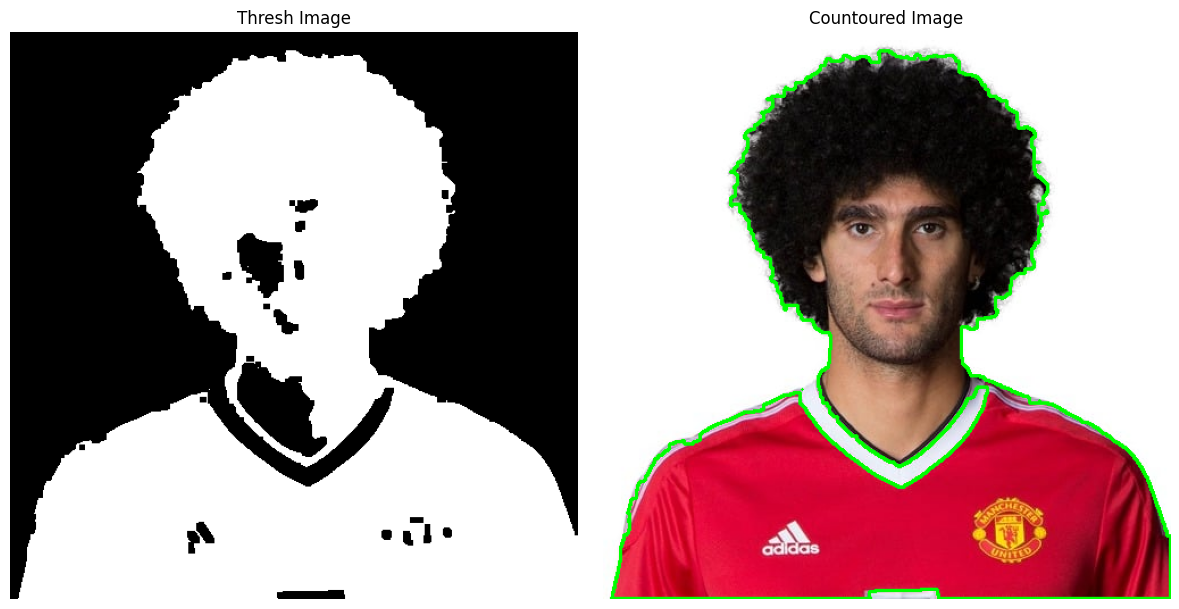

In [14]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Görüntüyü BGR ve gri olarak oku
my_bgr_img = cv2.imread("./Hafta_7/bonus.jpg")
my_gray_img = cv2.imread("./Hafta_7/bonus.jpg", 0)

# Ters binary eşikleme + Otsu yöntemi
ret, thresh = cv2.threshold(my_gray_img, 127, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Morfolojik "close" işlemi
kernel = np.ones((3,3), dtype=np.uint8)
thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=2)

# Konturları bul
contours, hierarchy = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Konturları çiz
contoured_img = my_bgr_img.copy()
cv2.drawContours(contoured_img, contours, -1, (0,255,0), 2)

# Yan yana gösterim
plt.figure(figsize=(12,6))

# 1. subplot → Morfolojik eşiklenmiş görüntü
plt.subplot(1,2,1)
plt.imshow(thresh, cmap='gray')
plt.title("Thresh Image")
plt.axis('off')

# 2. subplot → Konturları çizilmiş görüntü
plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(contoured_img, cv2.COLOR_BGR2RGB))
plt.title("Countoured Image")
plt.axis('off')

plt.tight_layout()
plt.show()


In [10]:
# ÖZET:

# - Görüntüler renkli (BGR) veya gri tonlamalı olarak okunabilir. 
#   Kontur analizi genellikle gri tonlamalı görüntüler üzerinde yapılır.
# - Eşikleme (thresholding) yöntemiyle görüntü siyah-beyaz (binary) hâline getirilir.
#   - THRESH_BINARY → belirli bir değerin üzerindeki pikseller beyaz yapılır.
#   - THRESH_BINARY_INV + THRESH_OTSU → ters binary ve otomatik eşikleme uygulanır.
# - Morfolojik işlemler (örneğin "closing") ile küçük boşluklar kapatılarak 
#   kontur tespiti daha doğru hâle getirilir.
# - CV2.FINDCONTOURS fonksiyonu ile binary görüntüdeki dış hatlar (konturlar) bulunur.
#   - İlk değer: kontur listesi
#   - İkinci değer: konturların hiyerarşik ilişkileri
# - CV2.DRAWCONTOURS ile bulunan konturlar orijinal görüntü üzerine çizdirilir.
#   - -1 → tüm konturlar çizilir
#   - (0,255,0) → yeşil renk
#   - 2 → çizgi kalınlığı
# - CV2.IMSHOW fonksiyonu ile hem binary hem de konturları çizilmiş görüntü görselleştirilir.
# - Bu konu, görüntülerde nesne sınırlarını tespit etmek, saymak, 
#   ve yapısal analiz yapmak için kullanılan temel görüntü işleme tekniklerini kapsar.
# - Kullanım alanları:
#   - Nesne ve şekil tespiti
#   - Görüntü segmentasyonu
#   - Bilgisayarla görme (Computer Vision) uygulamaları
#   - Eğitim ve araştırma amaçlı kontur analizi
